In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kmader_skin_cancer_mnist_ham10000_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')

print('Data source import complete.')


In [ ]:
! ls /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000

ham10000_images_part_1	HAM10000_images_part_2	hmnist_28_28_RGB.csv
HAM10000_images_part_1	HAM10000_metadata.csv	hmnist_8_8_L.csv
ham10000_images_part_2	hmnist_28_28_L.csv	hmnist_8_8_RGB.csv


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

Device: cuda


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define base paths (adjust if you are running locally instead of Kaggle)
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
csv_path = os.path.join(base_dir, 'HAM10000_metadata.csv')

In [ ]:
# Cell 2: Load metadata and map image paths
df = pd.read_csv(csv_path)

# Create a dictionary mapping image_id to the actual file path
image_paths = {}
for part in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    folder_path = os.path.join(base_dir, part)
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith('.jpg'):
                image_id = os.path.splitext(file)[0]
                image_paths[image_id] = os.path.join(folder_path, file)

# Add the file path to the dataframe
df['path'] = df['image_id'].map(image_paths)

# Map the short 'dx' codes to their full medical names for clarity
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict)

print(f"Total records loaded: {len(df)}")
display(df.sample(10))

Total records loaded: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type
2465,HAM_0007141,ISIC_0031513,bcc,histo,50.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Basal cell carcinoma
9229,HAM_0001541,ISIC_0028766,nv,consensus,30.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
1357,HAM_0007620,ISIC_0030089,mel,histo,55.0,female,back,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanoma
5046,HAM_0000414,ISIC_0032451,nv,follow_up,65.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
4000,HAM_0005179,ISIC_0024957,nv,follow_up,80.0,male,lower extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
7027,HAM_0005886,ISIC_0031622,nv,histo,50.0,female,upper extremity,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
6521,HAM_0007584,ISIC_0025139,nv,follow_up,35.0,female,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
1463,HAM_0006435,ISIC_0034071,mel,histo,50.0,male,back,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanoma
4152,HAM_0007224,ISIC_0024977,nv,follow_up,60.0,male,trunk,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanocytic nevi
2246,HAM_0004559,ISIC_0028220,mel,histo,60.0,male,face,/kaggle/input/datasets/kmader/skin-cancer-mnis...,Melanoma


In [ ]:
# Cell 3: Check for missing values
print("Dataset Info:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

# Age has a few missing values. For EDA, we can fill them with the mean age.
df['age'].fillna(df['age'].mean(), inplace=True)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   path          10015 non-null  object 
 8   cell_type     10015 non-null  object 
dtypes: float64(1), object(8)
memory usage: 704.3+ KB
None

Missing values per column:
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
path             0
cell_type        0
dtype: int64


/tmp/ipykernel_57/2923891934.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


/tmp/ipykernel_57/2419918595.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='cell_type', order=df['cell_type'].value_counts().index, palette='viridis')


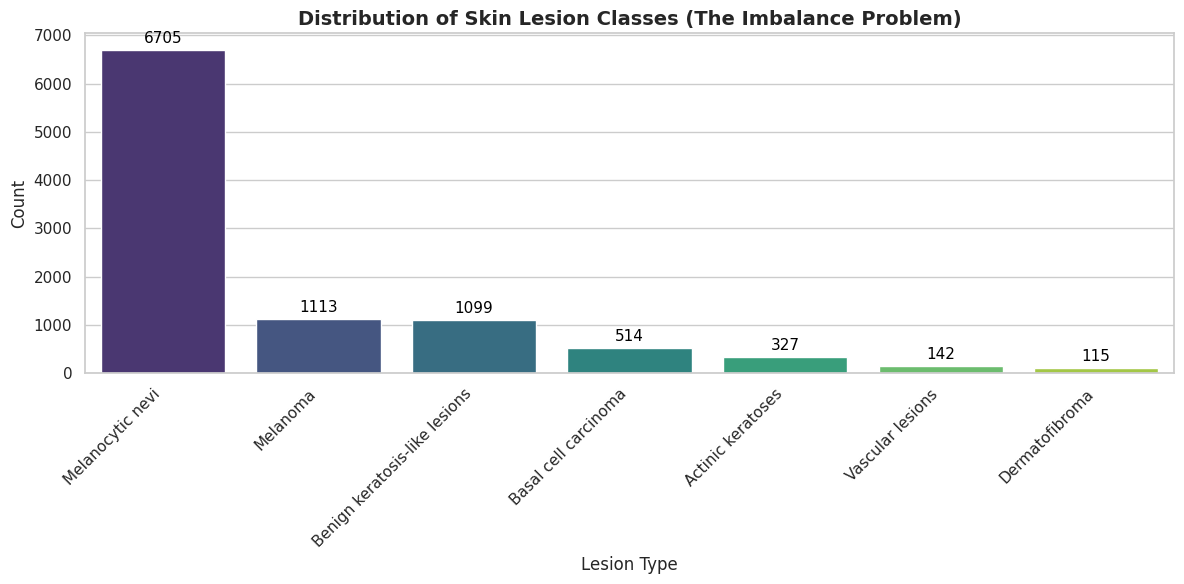

In [ ]:
# Cell 4: Distribution of target classes
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='cell_type', order=df['cell_type'].value_counts().index, palette='viridis')

# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline',
                fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Skin Lesion Classes (The Imbalance Problem)', fontsize=14, fontweight='bold')
plt.xlabel('Lesion Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57/2325564453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sex_data, x='sex', ax=axes[1], palette='pastel')


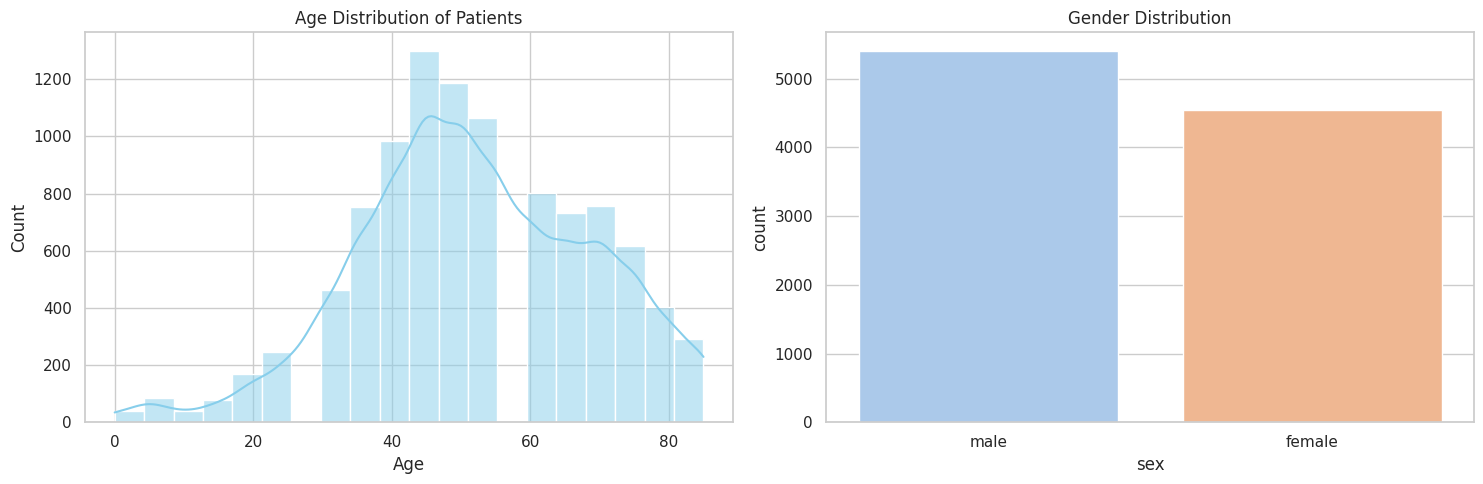

In [ ]:
# Cell 5: Age and Sex Distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Age distribution
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution of Patients')
axes[0].set_xlabel('Age')

# Sex distribution (excluding 'unknown')
sex_data = df[df['sex'] != 'unknown']
sns.countplot(data=sex_data, x='sex', ax=axes[1], palette='pastel')
axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.show()

/tmp/ipykernel_57/3193314485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index, palette='crest')


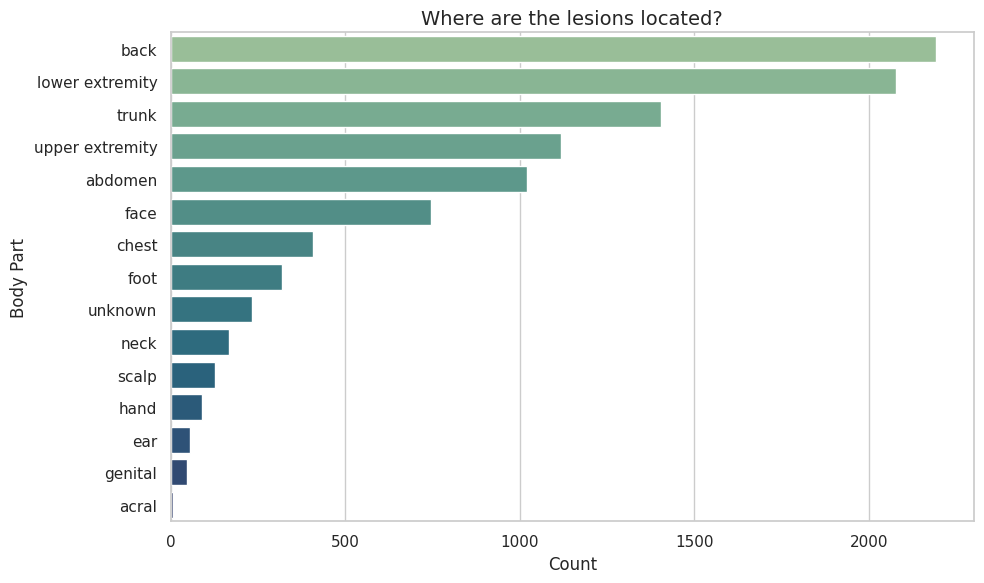

In [ ]:
# Cell 6: Anatomical Localization of Lesions
plt.figure(figsize=(10, 6))
sns.countplot(y='localization', data=df, order=df['localization'].value_counts().index, palette='crest')
plt.title('Where are the lesions located?', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Body Part')
plt.tight_layout()
plt.show()

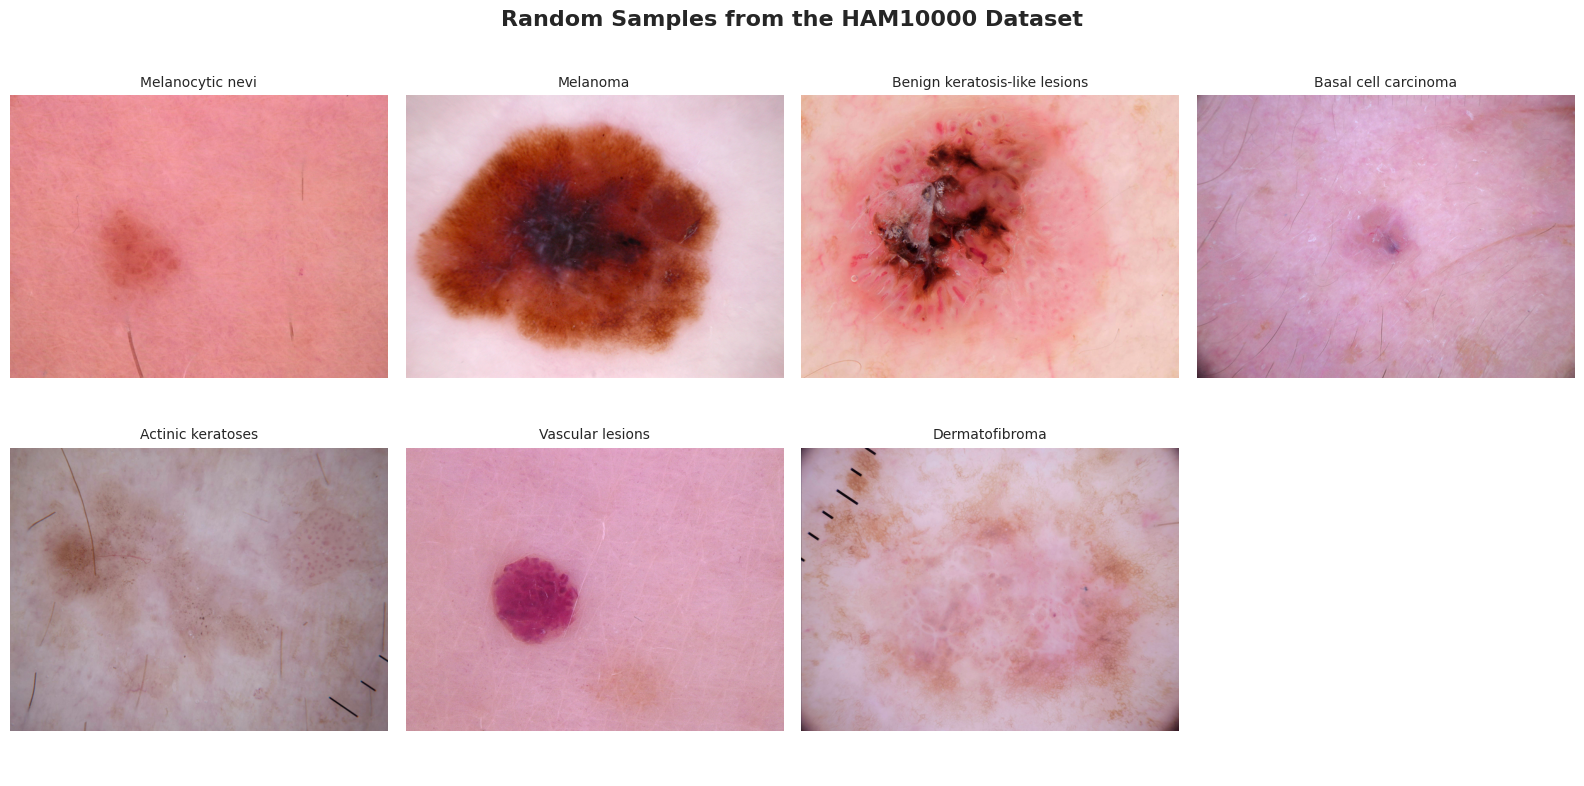

In [ ]:
# Cell 7: Display one random sample from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Iterate through the unique classes
for i, (lesion_type, class_name) in enumerate(lesion_type_dict.items()):
    # Get a random image path for this class
    sample_path = df[df['dx'] == lesion_type]['path'].sample(1).values[0]

    # Load and display the image
    img = Image.open(sample_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

# Hide the empty 8th subplot
axes[7].axis('off')

plt.suptitle('Random Samples from the HAM10000 Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
path            0
cell_type       0
dtype: int64

In [ ]:
# --- Augmentation (stronger for rarer classes) ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# --- Dataset class that handles both image folders ---
class HAMDataset(Dataset):
    def __init__(self, df, img_dirs, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dirs = img_dirs  # list of both part_1 and part_2 paths
        self.transform = transform
        self.label_map = {
            'nv':0, 'mel':1, 'bkl':2, 'bcc':3,
            'akiec':4, 'vasc':5, 'df':6
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'image_id']
        label  = self.label_map[self.df.loc[idx, 'dx']]

        # Search both folders
        img_path = None
        for d in self.img_dirs:
            p = os.path.join(d, img_id + '.jpg')
            if os.path.exists(p):
                img_path = p
                break

        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
# Drop duplicate lesions (same lesion, multiple images)
df = df.drop_duplicates(subset='lesion_id')

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['dx'], random_state=42
)

# --- Oversample minority classes in train_df only ---
target_count = 2000
augmented_dfs = []

for cls in train_df['dx'].unique():
    cls_df = train_df[train_df['dx'] == cls]
    if len(cls_df) < target_count:
        # Oversample with replacement
        cls_df = cls_df.sample(target_count, replace=True, random_state=42)
    else:
        # Undersample nv to 2000 for balance
        cls_df = cls_df.sample(target_count, replace=False, random_state=42)
    augmented_dfs.append(cls_df)

balanced_train_df = pd.concat(augmented_dfs).sample(frac=1, random_state=42)
print(balanced_train_df['dx'].value_counts())  # should be ~2000 each

dx
mel      2000
vasc     2000
akiec    2000
bkl      2000
bcc      2000
df       2000
nv       2000
Name: count, dtype: int64


In [ ]:
img_dirs = [
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'
]

train_dataset = HAMDataset(balanced_train_df, img_dirs, transform=train_transforms)
val_dataset   = HAMDataset(val_df, img_dirs, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 14000 | Val: 1494


In [ ]:
label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}

y_train = balanced_train_df['dx'].map(label_map).values

weights = compute_class_weight('balanced',
                                classes=np.array([0,1,2,3,4,5,6]),
                                y=y_train)

class_weights = torch.FloatTensor(weights).to(device)
print("Class weights:", class_weights)

Class weights: tensor([1., 1., 1., 1., 1., 1., 1.], device='cuda:0')


In [ ]:
model = models.convnext_base(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = True

# Replace ConvNeXt classifier head
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 7)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 179MB/s] 


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adamax(model.parameters(), lr=0.0001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

In [ ]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss/len(loader), 100.*correct/total


def val_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss/len(loader), 100.*correct/total, all_preds, all_labels

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_score = None

    def __call__(self, val_acc):
        if self.best_score is None or val_acc > self.best_score:
            self.best_score = val_acc
            self.counter = 0
            return False
        else:
            self.counter += 1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            return self.counter >= self.patience

In [ ]:
EPOCHS = 30
best_val_acc = 0
early_stopping = EarlyStopping(patience=5)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, preds, labels = val_epoch(model, val_loader, criterion)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✅ Best model saved ({val_acc:.2f}%)")

    if early_stopping(val_acc):
        print("Early stopping triggered.")
        break

print(f"\nBest Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30 | Train Loss: 0.7384 Acc: 74.35% | Val Loss: 0.5961 Acc: 76.64% | LR: 0.000100
  ✅ Best model saved (76.64%)
Epoch 2/30 | Train Loss: 0.3504 Acc: 87.59% | Val Loss: 0.4688 Acc: 82.20% | LR: 0.000100
  ✅ Best model saved (82.20%)
Epoch 3/30 | Train Loss: 0.2335 Acc: 91.86% | Val Loss: 0.5117 Acc: 80.59% | LR: 0.000100
  EarlyStopping: 1/5
Epoch 4/30 | Train Loss: 0.1774 Acc: 94.11% | Val Loss: 0.4281 Acc: 85.21% | LR: 0.000100
  ✅ Best model saved (85.21%)
Epoch 5/30 | Train Loss: 0.1320 Acc: 95.49% | Val Loss: 0.4897 Acc: 85.14% | LR: 0.000100
  EarlyStopping: 1/5
Epoch 6/30 | Train Loss: 0.1084 Acc: 96.30% | Val Loss: 0.4708 Acc: 85.48% | LR: 0.000100
  ✅ Best model saved (85.48%)
Epoch 7/30 | Train Loss: 0.0902 Acc: 96.97% | Val Loss: 0.5422 Acc: 84.47% | LR: 0.000100
  EarlyStopping: 1/5
Epoch 8/30 | Train Loss: 0.0736 Acc: 97.57% | Val Loss: 0.5354 Acc: 86.01% | LR: 0.000100
  ✅ Best model saved (86.01%)
Epoch 9/30 | Train Loss: 0.0624 Acc: 97.95% | Val Loss: 0.5401 Acc:

In [ ]:
class_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

model.load_state_dict(torch.load('best_model.pth'))
_, _, preds, true_labels = val_epoch(model, val_loader, criterion)

print(classification_report(true_labels, preds, target_names=class_names))
print("Balanced Accuracy:", balanced_accuracy_score(true_labels, preds))

              precision    recall  f1-score   support

          nv       0.96      0.93      0.95      1080
         mel       0.58      0.58      0.58       123
         bkl       0.77      0.72      0.74       145
         bcc       0.71      0.92      0.80        65
       akiec       0.51      0.78      0.62        46
        vasc       0.78      0.90      0.84        20
          df       0.91      0.67      0.77        15

    accuracy                           0.87      1494
   macro avg       0.75      0.79      0.76      1494
weighted avg       0.88      0.87      0.88      1494

Balanced Accuracy: 0.7854729883636163


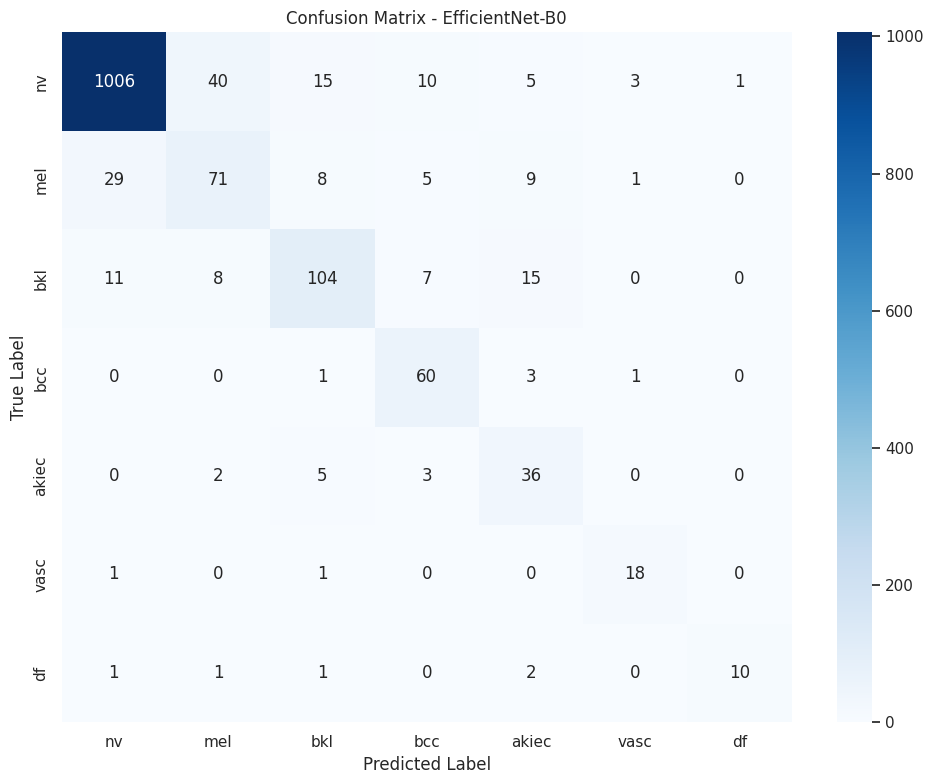

In [ ]:
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.title('Confusion Matrix - EfficientNet-B0')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()